¡Dataset cargado con éxito!
✅ Normalización por sujeto completada con éxito.
💾 Archivo exportado exitosamente como 'dataset_features_eeg_normalizado.csv'.


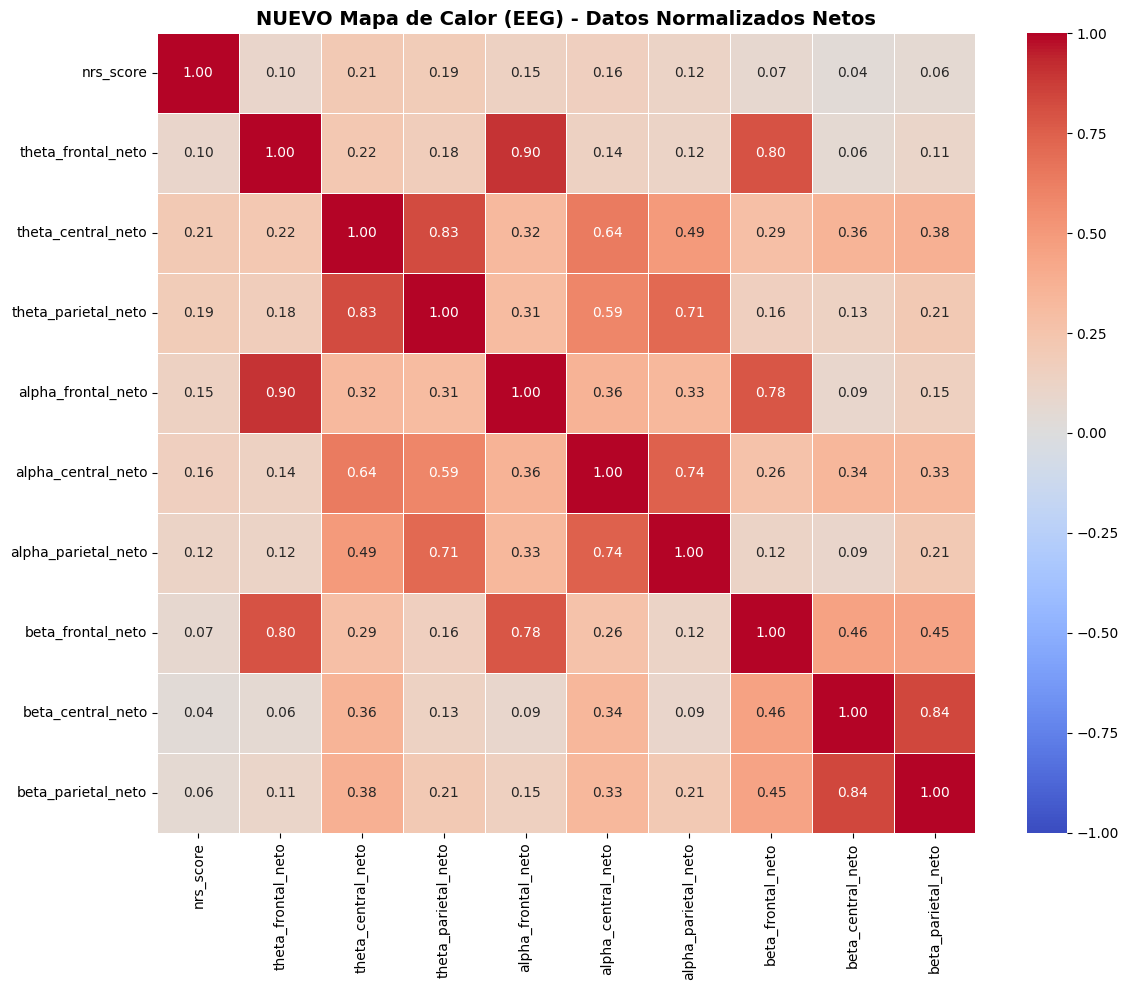

In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 1. CARGA DEL DATASET
# ==========================================
ruta_archivo = "/content/dataset_features_eeg.csv"

if os.path.exists(ruta_archivo):
    df_eeg = pd.read_csv(ruta_archivo)
    print("¡Dataset cargado con éxito!")
else:
    print(f"Error: No se encontró el archivo en la ruta {ruta_archivo}.")

# ==========================================
# 2. DEFINICIÓN DE VARIABLES
# ==========================================
bandas = [
    "theta_frontal", "theta_central", "theta_parietal",
    "alpha_frontal", "alpha_central", "alpha_parietal",
    "beta_frontal", "beta_central", "beta_parietal"
]
target = "nrs_score"
columna_sujeto = "subject_id"

# Aseguramos que el target sea numérico por si se cargó como texto
df_eeg[target] = pd.to_numeric(df_eeg[target], errors='coerce')

# ==========================================
# 3. TRANSFORMACIÓN LOGARÍTMICA PREVENTIVA
# ==========================================
df_log = df_eeg.copy()
for b in bandas:
    df_log[b] = np.log10(df_eeg[b] + 1e-9)

# ==========================================
# 4. CÁLCULO DE BASELINE CON TRANSFORM (SÚPER SEGURO)
# ==========================================
df_neto = df_log[[columna_sujeto, target]].copy()

# Encontramos el valor mínimo de dolor por sujeto si es que no existe un "0" estricto
# Esto asegura que el baseline represente el estado de menor dolor registrado de cada uno
for col in bandas:
    # Agrupamos por sujeto y calculamos el promedio de la onda SOLO cuando el dolor es el mínimo
    baseline_por_sujeto = df_log.groupby(columna_sujeto)[col].transform(
        lambda x: x[df_log.loc[x.index, target] == df_log.loc[x.index, target].min()].mean()
    )

    # Restamos la potencia espectral bruta menos su baseline correspondiente
    df_neto[f'{col}_neto'] = df_log[col] - baseline_por_sujeto

print("✅ Normalización por sujeto completada con éxito.")

# ==========================================
# 5. EXPORTAR EL DATASET REQUERIDO POR LA RÚBRICA
# ==========================================
ruta_salida = "dataset_features_eeg_normalizado.csv"
df_neto.to_csv(ruta_salida, index=False)
print(f"💾 Archivo exportado exitosamente como '{ruta_salida}'.")

# ==========================================
# 6. GRAFICAR Y EXPORTAR EL NUEVO HEATMAP
# ==========================================
columnas_heatmap = [target] + [f'{col}_neto' for col in bandas]

# Dropear NaNs si quedara alguno por registros incompletos antes de calcular la matriz
matriz_neto = df_neto[columnas_heatmap].dropna().corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_neto,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white"
)
plt.title('NUEVO Mapa de Calor (EEG) - Datos Normalizados Netos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nuevo_mapa_calor_eeg.png', dpi=150)
plt.show()

In [3]:
print(df_eeg.columns.tolist())

['subject_id', 'trial_num', 'nrs_score', 'theta_frontal', 'theta_central', 'theta_parietal', 'alpha_frontal', 'alpha_central', 'alpha_parietal', 'beta_frontal', 'beta_central', 'beta_parietal']
